# 🏅 Olympic Games Data Analysis (1896 – 2016)

**A beginner-friendly exploratory data analysis (EDA) portfolio project**

---

## About this project
The Olympic Games bring together thousands of athletes from over 200 National Olympic Committees (NOCs). In this project I explore a dataset of Olympic athletes to understand **who competes, how the Games have changed over time, and which countries and sports stand out**.

## Dataset
The file `dataset_olympics.csv` has **70,000 rows and 15 columns**. Each row is **one athlete's entry in one event**, so the same athlete can appear several times (for example, in different events or different Games). This means that most counts in this notebook are *entries*, not unique people.

| Column | Meaning |
|---|---|
| `ID`, `Name` | Athlete identifier and name |
| `Sex`, `Age`, `Height`, `Weight` | Athlete details (height in cm, weight in kg) |
| `Team`, `NOC` | Team name and 3-letter National Olympic Committee code |
| `Games`, `Year`, `Season`, `City` | Which Games, when, Summer/Winter, and the host city |
| `Sport`, `Event` | The sport and the specific event |
| `Medal` | Gold / Silver / Bronze (empty = no medal) |

## Questions I want to answer
1. What does the data look like, and how clean is it?
2. What is the typical Olympic athlete (age, height, weight, sex)?
3. How have participation, athlete age and medals changed over the years?
4. Which countries, athletes and sports dominate?
5. Do physical traits relate to winning medals?

## Contents
1. Setup and loading the data
2. Data overview
3. Data cleaning
4. Univariate analysis (one variable at a time)
5. Trends over time
6. Countries, sports and athletes
7. Physical traits and medals
8. Conclusion

## 1. Setup and loading the data

In [1]:
# Libraries for data handling and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# One consistent look for every chart
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

# Medal colours used in the charts below
MEDAL_COLORS = {"Gold": "#D4AF37", "Silver": "#A8A9AD", "Bronze": "#CD7F32"}

In [2]:
# Load the dataset (keep the CSV inside a 'data' folder next to this notebook)
data = pd.read_csv('data/dataset_olympics.csv')

## 2. Data overview
Before analysing anything, I check the structure of the data: the columns, data types, summary statistics and missing values.

In [3]:
# Column names
data.columns

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='str')

In [4]:
# First 5 rows
data.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [5]:
# Data types and non-null counts per column
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      70000 non-null  int64  
 1   Name    70000 non-null  str    
 2   Sex     70000 non-null  str    
 3   Age     67268 non-null  float64
 4   Height  53746 non-null  float64
 5   Weight  52899 non-null  float64
 6   Team    70000 non-null  str    
 7   NOC     70000 non-null  str    
 8   Games   70000 non-null  str    
 9   Year    70000 non-null  int64  
 10  Season  70000 non-null  str    
 11  City    70000 non-null  str    
 12  Sport   70000 non-null  str    
 13  Event   70000 non-null  str    
 14  Medal   9690 non-null   str    
dtypes: float64(3), int64(2), str(10)
memory usage: 8.0 MB


In [6]:
# Summary statistics for numeric columns
data.describe()

,ID,Age,Height,Weight,Year
count,70000.000000,67268.000000,53746.000000,52899.000000,70000.000000
mean,18081.846986,25.644645,175.505303,70.900216,1977.766457
std,10235.613253,6.485239,10.384203,14.217489,30.103306
min,1.000000,11.000000,127.000000,25.000000,1896.000000
25%,9325.750000,21.000000,168.000000,61.000000,1960.000000
50%,18032.000000,25.000000,175.000000,70.000000,1984.000000
75%,26978.000000,28.000000,183.000000,79.000000,2002.000000
max,35658.000000,88.000000,223.000000,214.000000,2016.000000


In [7]:
# Summary for the text columns (unique values, most frequent value)
data.select_dtypes(exclude='number').describe()

,Name,Sex,Team,NOC,Games,Season,City,Sport,Event,Medal
count,70000,70000,70000,70000,70000,70000,70000,70000,70000,9690
unique,35556,2,827,226,51,2,42,65,744,3
top,Oksana Aleksandrovna Chusovitina,M,United States,USA,2016 Summer,Summer,London,Athletics,Football Men's Football,Gold
freq,29,51877,4979,5216,3675,58467,6034,10629,1738,3292


In [8]:
# Missing values per column
data.isna().sum()

ID            0
Name          0
Sex           0
Age        2732
Height    16254
Weight    17101
Team          0
NOC           0
Games         0
Year          0
Season        0
City          0
Sport         0
Event         0
Medal     60310
dtype: int64

In [9]:
# Rows and columns
data.shape

(70000, 15)

### What I learned from the overview
- The dataset has **70,000 rows × 15 columns**, with **35,556 unique athlete names** and **51 Games** across **226 NOCs**, **65 sports** and **744 events**.
- **Age** is missing in about **3.9%** of rows, **Height** in about **23%** and **Weight** in about **24%**. Analyses of height and weight therefore use only the rows where those values exist.
- **Medal** is empty in about **86%** of rows. This is *not* bad data: an empty value simply means the athlete did not win a medal (9,690 rows have a medal).
- Typical values look realistic: median age is **25**, mean height is about **175.5 cm** and mean weight is about **70.9 kg**. The youngest athlete is 11 and the oldest is 88.

## 3. Data cleaning
The only real cleaning issue is duplicate rows. I remove them so that nothing is counted twice. I deliberately **keep** the missing Age, Height and Weight values (instead of filling them in) because inventing values would distort the averages. Pandas skips missing values automatically when calculating means.

In [10]:
# How many exact duplicate rows are there?
data.duplicated().sum()

np.int64(383)

In [11]:
# Remove the duplicates
data.drop_duplicates(inplace=True)

In [12]:
# Confirm that no duplicates remain
data.duplicated().sum()

np.int64(0)

**Result:** 383 duplicate rows were found and removed, leaving about **69,617 rows** for the analysis.

## 4. Univariate analysis
Here I look at one variable at a time to understand the typical Olympic athlete.

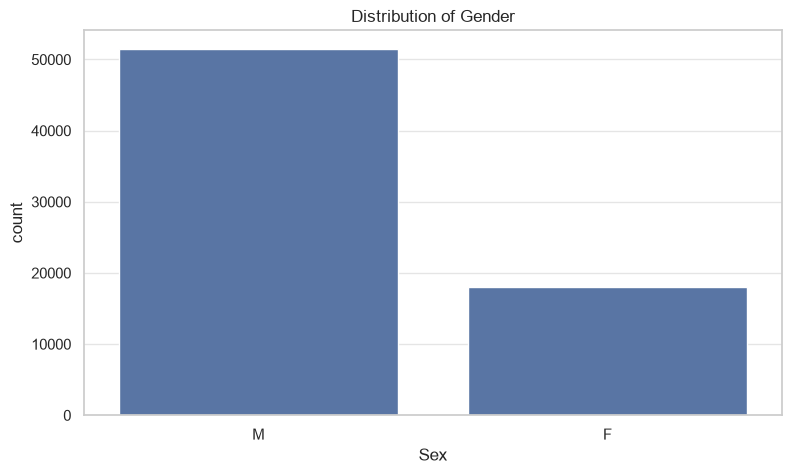

In [13]:
# How many male vs female entries?
sns.countplot(data=data, x='Sex')
plt.title('Distribution of Gender')
plt.show()

**Insight:** Male entries dominate the dataset, making up roughly **three quarters** of all rows (51,877 of 70,000 before duplicates were removed). Section 5 shows how the female share has changed over time.

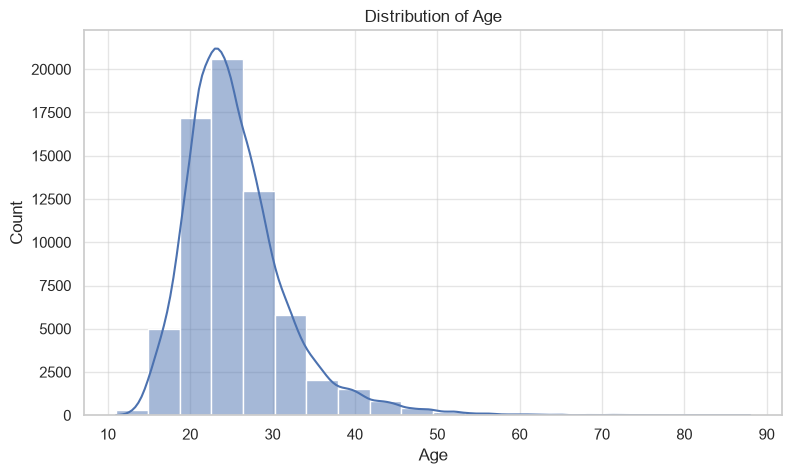

In [15]:
# Age distribution of athletes
sns.histplot(data=data, x='Age', bins=20, kde=True)
plt.title('Distribution of Age')
plt.show()

**Insight:** Age is **right-skewed**. Most athletes are between about **21 and 28** (the middle 50%), and the median is **25**. A small number of older athletes stretch the tail out to 88.

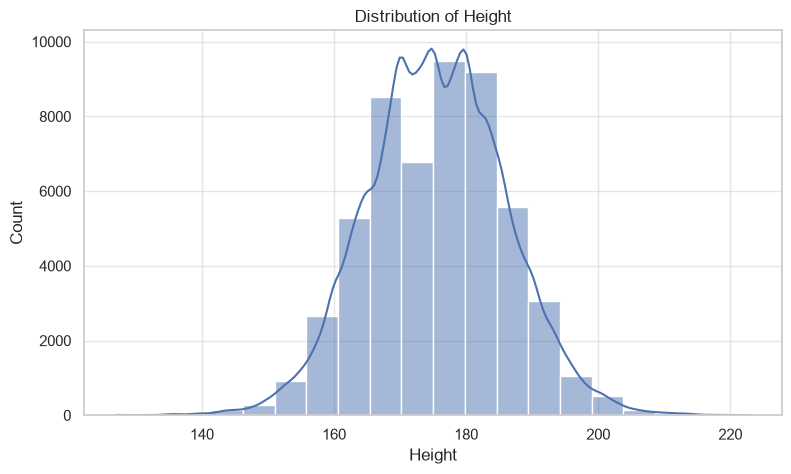

In [16]:
# Height distribution of athletes
sns.histplot(data=data, x='Height', bins=20, kde=True)
plt.title('Distribution of Height')
plt.show()

**Insight:** Height is roughly **bell-shaped** and centred near 175 cm, but with two small peaks (around 170 and 180 cm). A likely reason is that male and female athletes are mixed together. The next chart checks this.

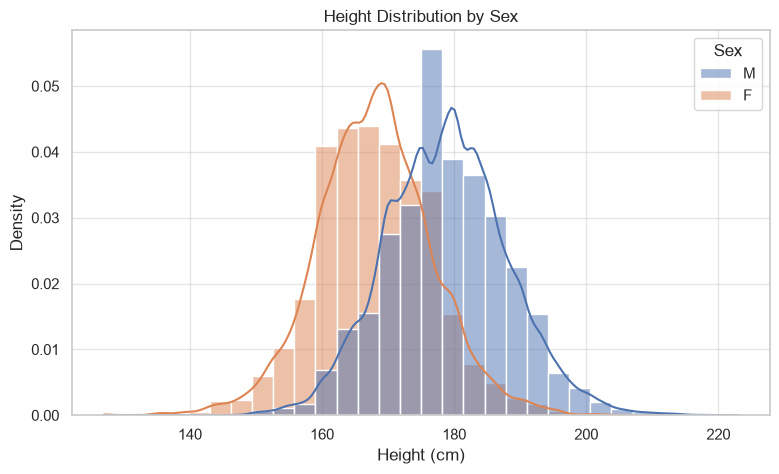

Average height: men 178.8 cm vs women 167.9 cm (difference of 10.9 cm)


In [17]:
# Does splitting by sex explain the two peaks in height?
sns.histplot(data=data, x='Height', hue='Sex', bins=30, kde=True,
             stat='density', common_norm=False)
plt.title('Height Distribution by Sex')
plt.xlabel('Height (cm)')
plt.show()

avg_height_by_sex = data.groupby('Sex')['Height'].mean().round(1)
print(f"Average height: men {avg_height_by_sex['M']} cm vs women {avg_height_by_sex['F']} cm "
      f"(difference of {avg_height_by_sex['M'] - avg_height_by_sex['F']:.1f} cm)")

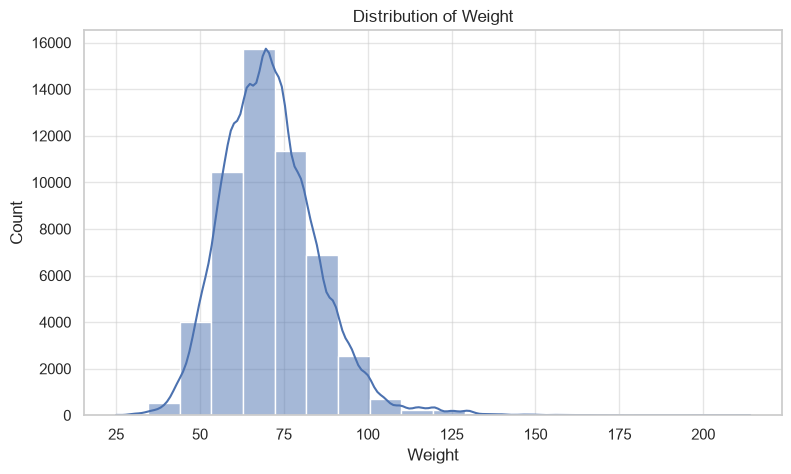

In [18]:
# Weight distribution of athletes
sns.histplot(data=data, x='Weight', bins=20, kde=True)
plt.title('Distribution of Weight')
plt.show()

**Insight:** Weight is **right-skewed**: most athletes weigh between about 60 and 80 kg, while a few heavyweight athletes (for example in judo) pull the tail out towards 200 kg.

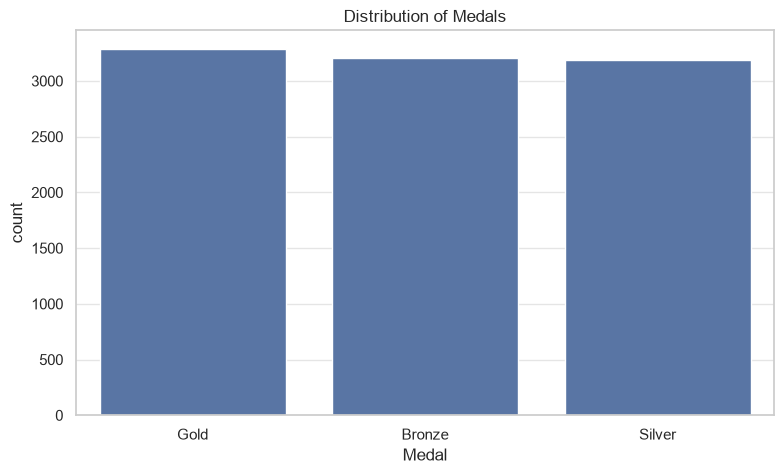

In [19]:
# How many Gold, Silver and Bronze medals?
sns.countplot(data=data, x='Medal')
plt.title("Distribution of Medals")
plt.show()

**Insight:** The three medal types are almost perfectly balanced, at roughly **3,200 each** (Gold is slightly highest with 3,292). This makes sense because every event awards one gold, one silver and one bronze. Note that in team events each team member gets a row, so one team medal adds several rows.

## 5. Trends over time
How have the Games grown and changed since 1896?

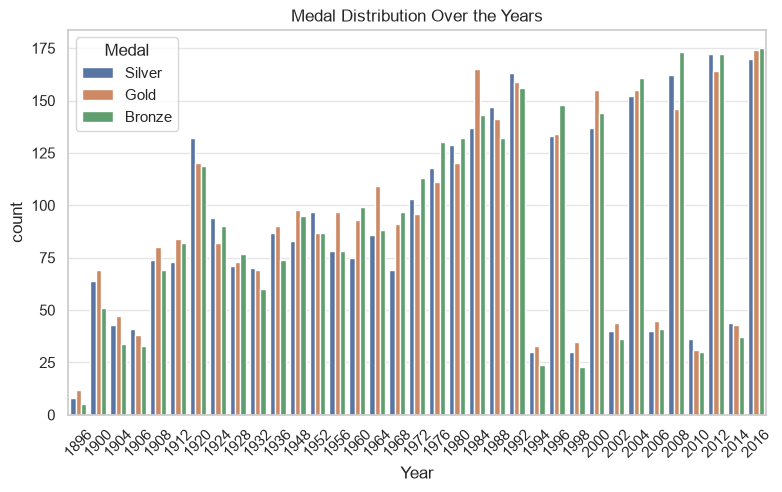

In [20]:
# Medals awarded in each Games year
sns.countplot(data=data, x="Year", hue="Medal")
plt.title("Medal Distribution Over the Years")
plt.xticks(rotation=45)
plt.show()

**Insight:** The number of medals (counted per athlete) **grows steadily over time**, reaching about 175 per medal type in the most recent Summer Games. The tall and short bars **alternate** from 1994 onwards. That is because Summer and Winter Games stopped being held in the same year and moved to a two-year cycle, and Winter Games have far fewer events.

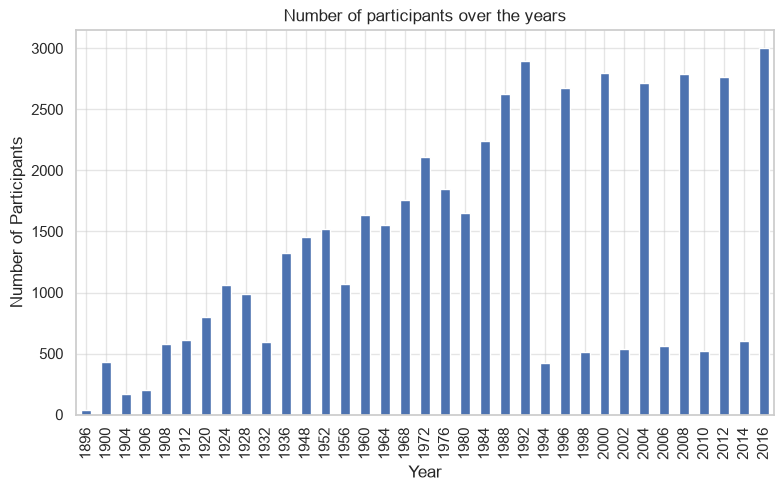

In [21]:
# Number of unique athletes in each Games year
year_participant_count = data.groupby("Year")["ID"].nunique()
year_participant_count.plot(kind="bar")
plt.title("Number of participants over the years")
plt.xlabel("Year")
plt.ylabel("Number of Participants")
plt.show()

**Insight:** Participation **grew from under 100 athletes in 1896 to about 3,000 in 2016** (in this sample). The same Summer/Winter alternation appears after 1992: Summer Games draw roughly 2,700 to 3,000 athletes while Winter Games draw about 400 to 600.

In [22]:
# Average athlete age in each Games year
year_avg_age = data.groupby('Year')['Age'].mean()
year_avg_age

Year
1896    23.029412
1900    29.119883
1904    27.063241
1906    26.989474
1908    27.000000
1912    27.965552
1920    29.241135
1924    28.252267
1928    27.973564
1932    29.606987
1936    27.245665
1948    28.363170
1952    26.273684
1956    26.316156
1960    25.136156
1964    24.852107
1968    24.316722
1972    24.126448
1976    23.656820
1980    23.312364
1984    24.060328
1988    24.257374
1992    24.637827
1994    24.487516
1996    25.338210
1998    25.143860
2000    25.435177
2002    26.029095
2004    25.780111
2006    26.091716
2008    25.685148
2010    26.150776
2012    25.993485
2014    26.082814
2016    26.259592
Name: Age, dtype: float64

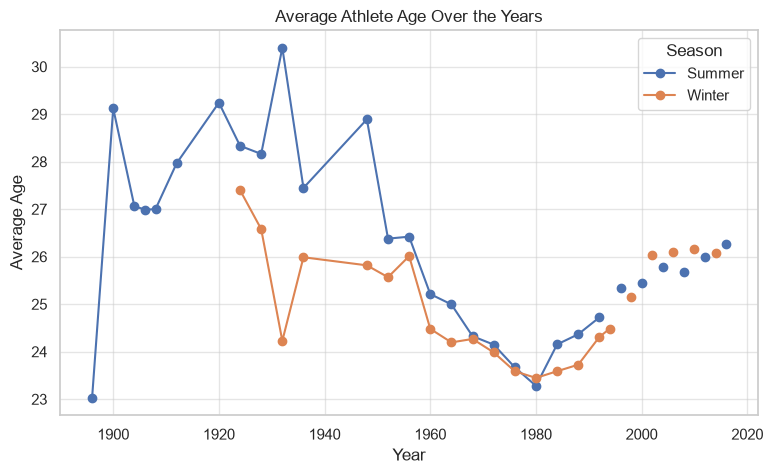

In [23]:
# Same numbers as a line chart, split by Summer and Winter
age_by_year_season = data.groupby(['Year', 'Season'])['Age'].mean().unstack()
age_by_year_season.plot(marker='o')
plt.title('Average Athlete Age Over the Years')
plt.xlabel('Year')
plt.ylabel('Average Age')
plt.legend(title='Season')
plt.show()

**Insight:** Athletes were **oldest in the early 20th century** (average about 29 to 30 in 1900 and 1932) and **youngest around 1980** (about 23.3). Since then the average has crept back up to about **26 years**, which possibly reflects athletes staying competitive for longer. (The 1896 average of 23 comes from a very small first Games.)

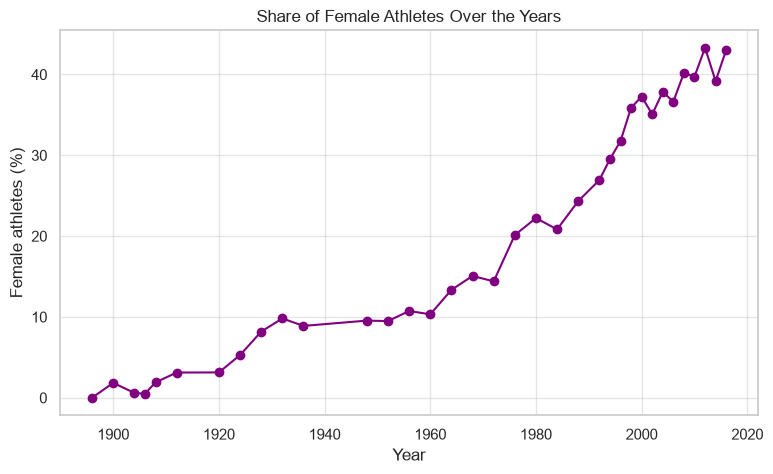

Finding: women first appear in 1900. By 2016 they make up 43.0% of athletes.


In [24]:
# Share of women among the athletes at each Games
sex_by_year = data.groupby(['Year', 'Sex'])['ID'].nunique().unstack(fill_value=0)
female_share = sex_by_year['F'] / sex_by_year.sum(axis=1) * 100

female_share.plot(marker='o', color='purple')
plt.title('Share of Female Athletes Over the Years')
plt.xlabel('Year')
plt.ylabel('Female athletes (%)')
plt.show()

first_year = female_share[female_share > 0].index.min()
print(f"Finding: women first appear in {first_year}. "
      f"By {female_share.index[-1]} they make up {female_share.iloc[-1]:.1f}% of athletes.")

**Insight:** Women were absent from the first Games and their share has risen steadily, which is one of the biggest changes in Olympic history. The finding line above gives the exact figures.

In [25]:
# Summer vs Winter: how big is each?
season_summary = data.groupby('Season').agg(
    entries=('ID', 'size'),
    athletes=('ID', 'nunique'),
    medal_rows=('Medal', 'count'),
)
season_summary['share_of_entries_%'] = (season_summary['entries'] / season_summary['entries'].sum() * 100).round(1)
season_summary

,entries,athletes,medal_rows,share_of_entries_%
Season,,,,
Summer,58084,31209,8400,83.4
Winter,11533,4486,1286,16.6


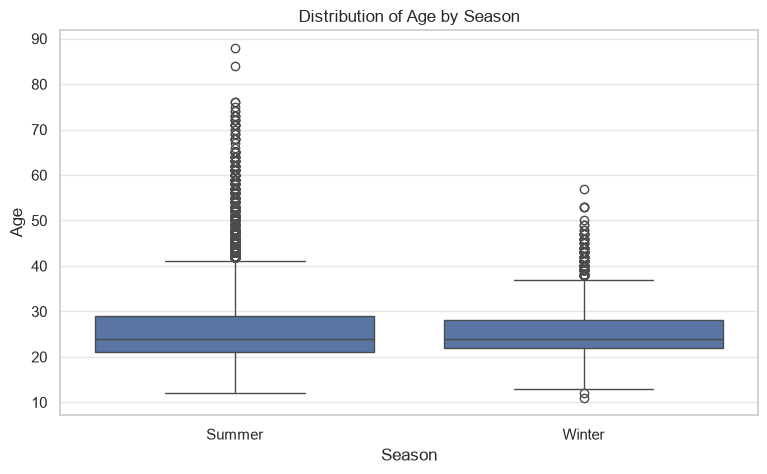

In [26]:
# Do Summer and Winter athletes differ in age?
sns.boxplot(data=data, x="Season", y="Age")
plt.title("Distribution of Age by Season")
plt.xlabel("Season")
plt.ylabel("Age")
plt.show()

**Insight:** The typical (median) age is almost the same in both seasons, at about 24. The difference is in the **outliers**: Summer has many more older athletes, with ages up to 88 compared to about 57 in Winter. Sports such as shooting and equestrian, where experience matters more than raw athleticism, are one possible explanation.

## 6. Countries, sports and athletes
Which countries, sports and athletes stand out?

In [72]:
# Which country sends the most athletes?
# NOTE: this counts athlete entries (rows), not medals; medals are analysed below.
top_entries = data["NOC"].value_counts()
print(f"The country with the most athlete entries is: {top_entries.index[0]}")

The country with the most athlete entries is: USA


In [44]:
# Number of male and female entries for each country
country_gender_count = data.groupby(['NOC', 'Sex'])['ID'].count()
country_gender_count

NOC  Sex
AFG  M       38
AHO  F        6
     M       27
ALB  F        4
     M        7
           ... 
YUG  M      455
ZAM  F        3
     M       40
ZIM  F       41
     M       47
Name: ID, Length: 432, dtype: int64

In [27]:
# Gold medal rows per country
# NOTE: team events give one row per athlete, so a team gold counts several times here.
country_gold_medals = data[data['Medal'] == 'Gold'].groupby('NOC')['Medal'].count()
country_gold_medals.max()

np.int64(747)

In [28]:
# Which country has the most gold medal rows?
country_gold_medals[country_gold_medals == country_gold_medals.max()]

NOC
USA    747
Name: Medal, dtype: int64

**Insight:** The **USA** leads on both participation and gold medals, with **747 gold medal rows**. Because team events are counted per athlete, this number is inflated compared with the official medal table, so I recount medals properly below.

### 6.1 Counting medals properly
To count each medal **once per country, event and Games** (so that a relay team's medal is not counted four times), I remove the duplicates among medal rows.

In [29]:
# All rows where the athlete won a medal (Medal is empty for non-medalists)
medals = data.dropna(subset=['Medal'])

# One medal per country / event / Games, so team medals are counted once
unique_medals = medals.drop_duplicates(subset=['Games', 'Event', 'NOC', 'Medal'])

print(f"Medal rows (one per athlete): {len(medals):,}")
print(f"Unique medals (one per country/event/Games): {len(unique_medals):,}")

Medal rows (one per athlete): 9,686
Unique medals (one per country/event/Games): 6,436


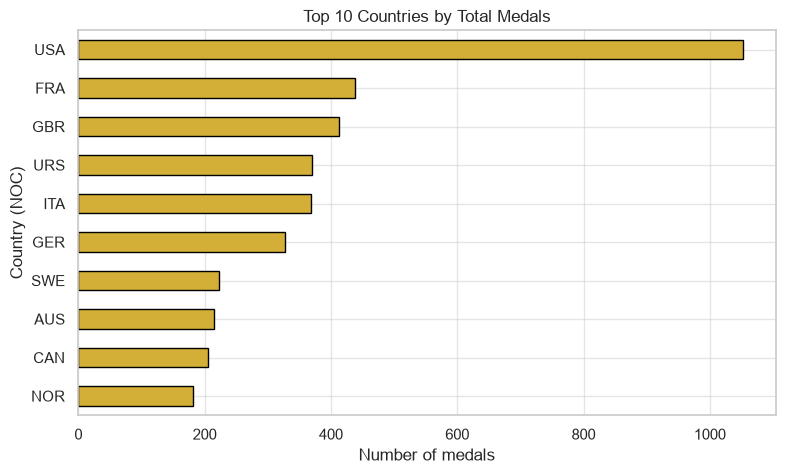

Finding: USA leads with 1,052 medals, followed by FRA (438) and GBR (413).


In [30]:
# Top 10 countries by unique medals
top_countries = unique_medals['NOC'].value_counts().head(10)

top_countries.sort_values().plot(kind='barh', color='#D4AF37', edgecolor='black')
plt.title('Top 10 Countries by Total Medals')
plt.xlabel('Number of medals')
plt.ylabel('Country (NOC)')
plt.show()

print(f"Finding: {top_countries.index[0]} leads with {top_countries.iloc[0]:,} medals, "
      f"followed by {top_countries.index[1]} ({top_countries.iloc[1]:,}) "
      f"and {top_countries.index[2]} ({top_countries.iloc[2]:,}).")

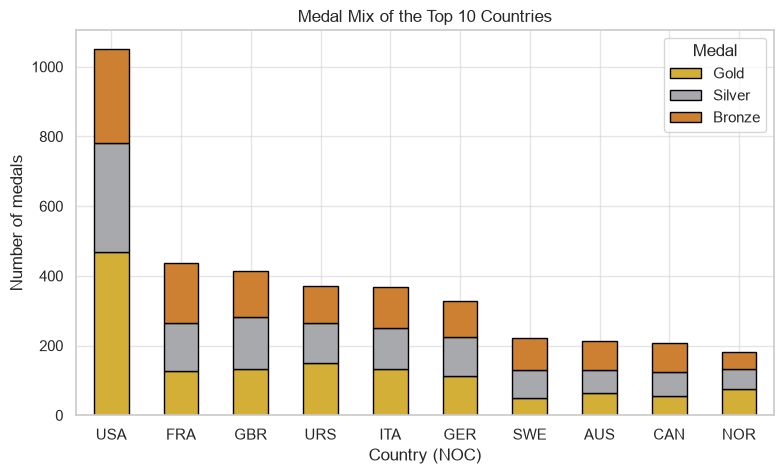

In [31]:
# Medal mix (gold / silver / bronze) of the top 10 countries
medal_mix = (unique_medals[unique_medals['NOC'].isin(top_countries.index)]
             .groupby(['NOC', 'Medal']).size().unstack(fill_value=0)
             .loc[top_countries.index, ['Gold', 'Silver', 'Bronze']])

medal_mix.plot(kind='bar', stacked=True,
               color=[MEDAL_COLORS[m] for m in medal_mix.columns], edgecolor='black')
plt.title('Medal Mix of the Top 10 Countries')
plt.xlabel('Country (NOC)')
plt.ylabel('Number of medals')
plt.xticks(rotation=0)
plt.show()

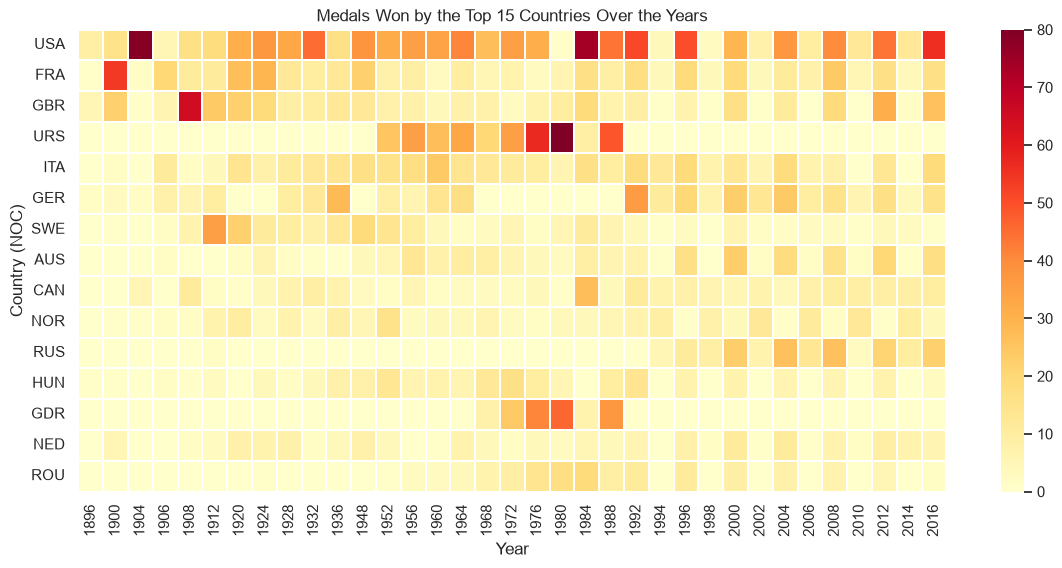

In [32]:
# Medals of the top 15 countries across the years
top15 = unique_medals['NOC'].value_counts().head(15).index

medal_pivot = (unique_medals[unique_medals['NOC'].isin(top15)]
               .pivot_table(index='NOC', columns='Year', values='Medal',
                            aggfunc='count', fill_value=0)
               .loc[top15])

plt.figure(figsize=(14, 6))
sns.heatmap(medal_pivot, cmap='YlOrRd', linewidths=0.3)
plt.title('Medals Won by the Top 15 Countries Over the Years')
plt.xlabel('Year')
plt.ylabel('Country (NOC)')
plt.show()

darker cells show the Games in which a country won the most medals.

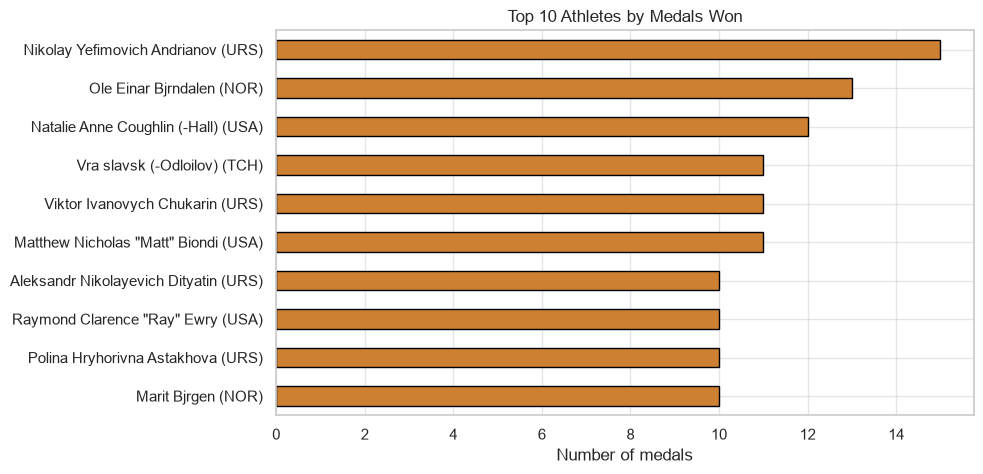

Finding: Nikolay Yefimovich Andrianov (URS) has the most medals in this dataset, with 15.


In [33]:
# Top 10 individual medalists (medal rows per athlete)
top_athletes = (medals.groupby(['Name', 'NOC']).size()
                .sort_values(ascending=False).head(10)
                .reset_index(name='medals'))
top_athletes['label'] = top_athletes['Name'] + ' (' + top_athletes['NOC'] + ')'

top_athletes.sort_values('medals').plot(kind='barh', x='label', y='medals',
                                        legend=False, color='#CD7F32', edgecolor='black')
plt.title('Top 10 Athletes by Medals Won')
plt.xlabel('Number of medals')
plt.ylabel('')
plt.show()

best = top_athletes.iloc[0]
print(f"Finding: {best['Name']} ({best['NOC']}) has the most medals in this dataset, with {best['medals']}.")

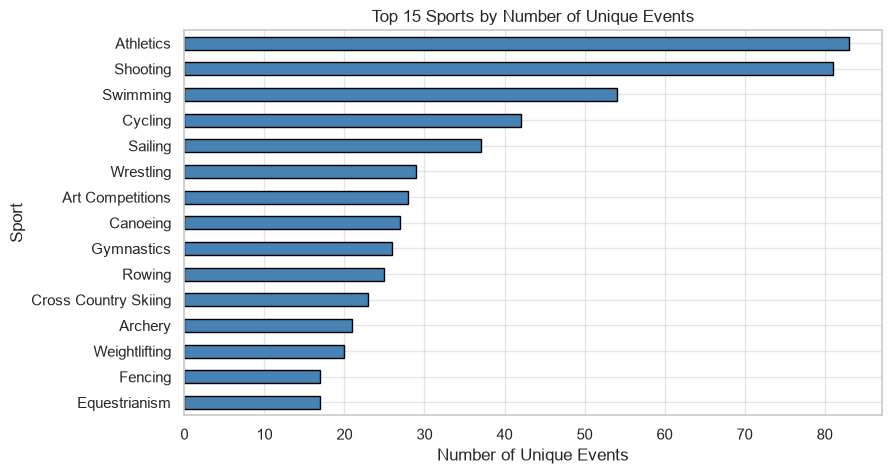

In [34]:
# Which sports have the most different events? (top 15 for readability)
sport_event_count = data.groupby("Sport")["Event"].nunique().sort_values(ascending=False)

sport_event_count.head(15).sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title("Top 15 Sports by Number of Unique Events")
plt.xlabel("Number of Unique Events")
plt.ylabel("Sport")
plt.show()

**Athletics and Shooting have the most events** (around 80 each in the original chart), well ahead of Swimming (about 54). Keep in mind that event names in this dataset include variations by gender and distance, so this is a count of distinct event labels.

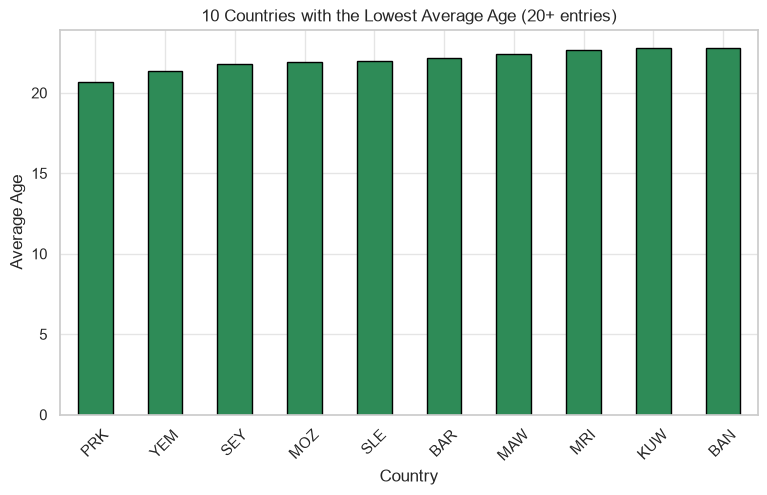

In [35]:
# Which countries have the YOUNGEST athletes on average?
# Countries with very few entries give extreme averages, so I only keep countries with 20+ entries.
entries_per_country = data['NOC'].value_counts()
big_countries = entries_per_country[entries_per_country >= 20].index

country_avg_age = (data[data['NOC'].isin(big_countries)]
                   .groupby('NOC')['Age'].mean().dropna().sort_values())

country_avg_age.head(10).plot(kind='bar', color='seagreen', edgecolor='black')
plt.title("10 Countries with the Lowest Average Age (20+ entries)")
plt.xlabel("Country")
plt.ylabel("Average Age")
plt.xticks(rotation=45)
plt.show()

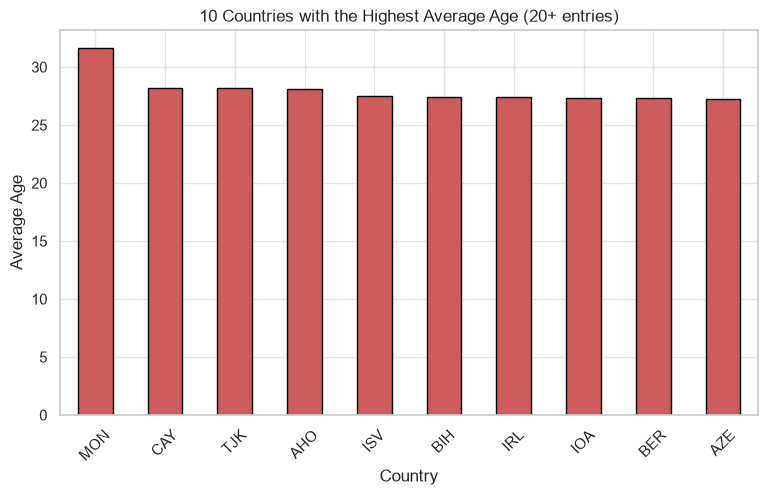

In [36]:
# Which countries have the OLDEST athletes on average? (same 20+ entries rule)
country_avg_age.tail(10).sort_values(ascending=False).plot(kind='bar', color='indianred', edgecolor='black')
plt.title("10 Countries with the Highest Average Age (20+ entries)")
plt.xlabel("Country")
plt.ylabel("Average Age")
plt.xticks(rotation=45)
plt.show()

**What changed and why:** In the original charts, two of the "youngest" countries (CRT and UNK) showed no bar at all because they had no age data, and the extremes (for example KIR at about 17 years, WIF at about 34.5) came from tiny delegations where one athlete moves the average a lot. Filtering to countries with **20 or more entries** and dropping missing ages gives a fairer comparison.

## 7. Physical traits and medals
Do height and weight vary by sport, and do they help athletes win medals?

In [37]:
# Average height of each sport
sport_avg_height = data.groupby("Sport")['Height'].mean()
round(sport_avg_height.max(), 2)

np.float64(190.77)

In [38]:
# Which sports have an average height of 190 cm or more?
sport_avg_height[sport_avg_height >= 190]

Sport
Basketball    190.768199
Name: Height, dtype: float64

**Insight:** **Basketball** is the only sport whose athletes average over 190 cm (about **190.8 cm**), which is far above the overall average of 175.5 cm.

In [39]:
# Average weight by sport and sex, e.g. female wrestlers
sport_gender_avg_weight = data.groupby(['Sport', 'Sex'])['Weight'].mean()
sport_gender_avg_weight["Wrestling"]["F"]

np.float64(58.16901408450704)

**Insight:** Female wrestlers weigh about **58.2 kg** on average. Combat sports have weight classes, so weight varies a lot between events within the same sport.

In [40]:
# The tallest athlete
tallest = data.loc[data['Height'].idxmax()]
print(f"The tallest athlete is {tallest['Name']} ({tallest['NOC']}) at {tallest['Height']:.0f} cm.")
data[data['Height'] == data['Height'].max()]

The tallest athlete is Tommy Loren Burleson (USA) at 223 cm.


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
32376,16639,Tommy Loren Burleson,M,20.0,223.0,102.0,United States,USA,1972 Summer,1972,Summer,Munich,Basketball,Basketball Men's Basketball,Silver


In [41]:
# The heaviest athlete
heaviest = data.loc[data['Weight'].idxmax()]
print(f"The heaviest athlete is {heaviest['Name']} ({heaviest['NOC']}) at {heaviest['Weight']:.0f} kg.")
data[data['Weight'] == data['Weight'].max()]

The heaviest athlete is Ricardo Blas, Jr. (GUM) at 214 kg.


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
23155,12177,"Ricardo Blas, Jr.",M,21.0,183.0,214.0,Guam,GUM,2008 Summer,2008,Summer,Beijing,Judo,Judo Men's Heavyweight,NaN
23156,12177,"Ricardo Blas, Jr.",M,25.0,183.0,214.0,Guam,GUM,2012 Summer,2012,Summer,London,Judo,Judo Men's Heavyweight,NaN


In [42]:
# The lightest athlete
# (the original version of this cell accidentally printed the heaviest athlete; fixed here)
lightest = data.loc[data['Weight'].idxmin()]
print(f"The lightest athlete is {lightest['Name']} ({lightest['NOC']}) at {lightest['Weight']:.0f} kg.")
data[data['Weight'] == data['Weight'].min()]

The lightest athlete is Choi Myong-Hui (PRK) at 25 kg.


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
40849,21049,Choi Myong-Hui,F,14.0,135.0,25.0,North Korea,PRK,1980 Summer,1980,Summer,Moskva,Gymnastics,Gymnastics Women's Individual All-Around,NaN
40850,21049,Choi Myong-Hui,F,14.0,135.0,25.0,North Korea,PRK,1980 Summer,1980,Summer,Moskva,Gymnastics,Gymnastics Women's Team All-Around,NaN
40851,21049,Choi Myong-Hui,F,14.0,135.0,25.0,North Korea,PRK,1980 Summer,1980,Summer,Moskva,Gymnastics,Gymnastics Women's Floor Exercise,NaN
40852,21049,Choi Myong-Hui,F,14.0,135.0,25.0,North Korea,PRK,1980 Summer,1980,Summer,Moskva,Gymnastics,Gymnastics Women's Horse Vault,NaN
40853,21049,Choi Myong-Hui,F,14.0,135.0,25.0,North Korea,PRK,1980 Summer,1980,Summer,Moskva,Gymnastics,Gymnastics Women's Uneven Bars,NaN
40854,21049,Choi Myong-Hui,F,14.0,135.0,25.0,North Korea,PRK,1980 Summer,1980,Summer,Moskva,Gymnastics,Gymnastics Women's Balance Beam,NaN


**Insight (the extremes):**
- **Tallest:** Tommy Burleson (USA), **223 cm**, a basketball player who won silver in 1972.
- **Heaviest:** Ricardo Blas Jr. (Guam), **214 kg**, a judoka in 2008 and 2012.
- **Lightest:** Choi Myong-Hui (North Korea), **25 kg**, a 14-year-old gymnast in 1980 (she appears several times because she entered several events).

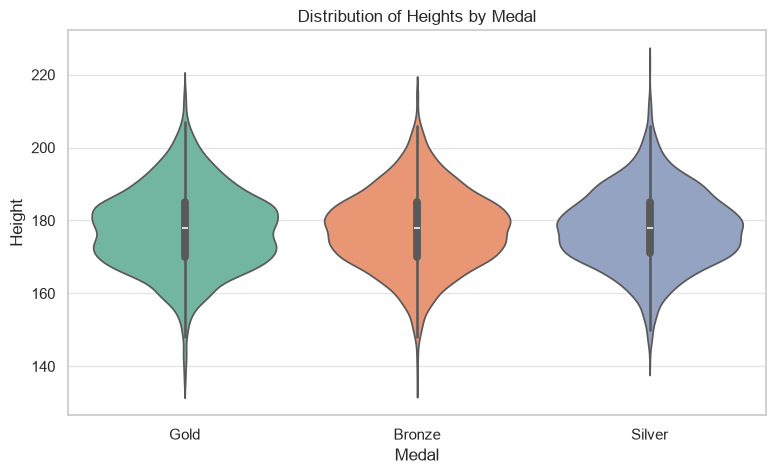

In [43]:
# Is height different for Gold, Silver and Bronze winners?
sns.violinplot(data=data, x="Medal", y="Height", hue="Medal", palette="Set2", legend=False)
plt.title("Distribution of Heights by Medal")
plt.xlabel("Medal")
plt.ylabel("Height")
plt.show()

**Insight:** The height distributions for Gold, Silver and Bronze winners are **almost identical** (median about 178 cm). Height alone does not decide who wins a particular medal.

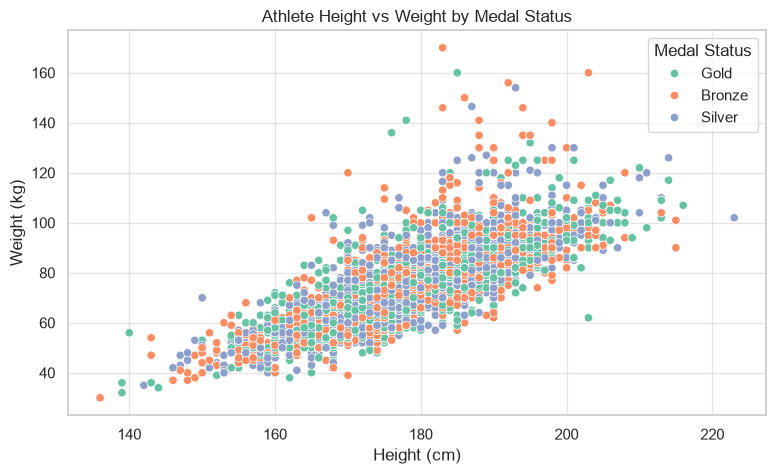

In [44]:
# Height vs weight, coloured by medal
sns.scatterplot(data=data, x="Height", y="Weight", hue="Medal", palette="Set2")
plt.title("Athlete Height vs Weight by Medal Status")
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.legend(title="Medal Status")
plt.show()

**Insight:** Height and weight have a clear **positive linear relationship** (taller athletes are heavier), and the three medal colours overlap almost completely. Winners come in all shapes and sizes. (Fixed the typo "Model Status" in the original title.)

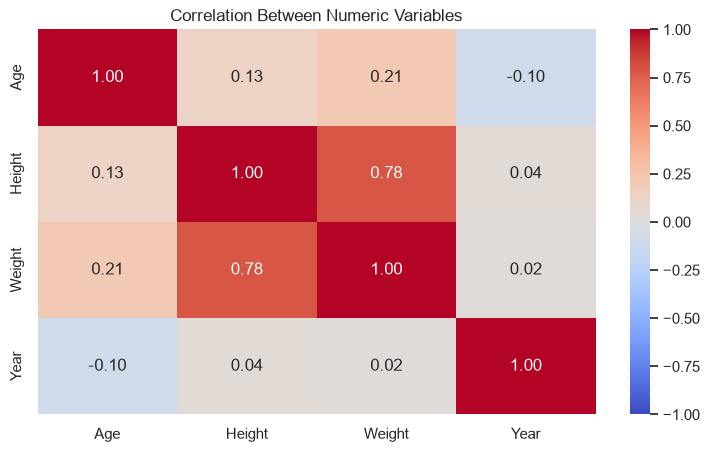

Finding: height and weight have a correlation of 0.78, while age and weight have only 0.21.


In [45]:
# Correlation between the numeric columns
corr = data[['Age', 'Height', 'Weight', 'Year']].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Between Numeric Variables')
plt.show()

print(f"Finding: height and weight have a correlation of {corr.loc['Height', 'Weight']:.2f}, "
      f"while age and weight have only {corr.loc['Age', 'Weight']:.2f}.")

In [46]:
# Do medalists differ from non-medalists on average?
data['Medalist'] = data['Medal'].notna()
medalist_comparison = data.groupby('Medalist')[['Age', 'Height', 'Weight']].mean().round(1)
medalist_comparison.index = ['Non-medalists', 'Medalists']
medalist_comparison

,Age,Height,Weight
Non-medalists,25.5,175.1,70.4
Medalists,26.1,177.8,73.9


**How to read this:** Compare the averages in the table. Keep in mind that any gap partly reflects **which sports** medalists compete in (team sports give many athletes a medal at once), not only the athletes themselves.

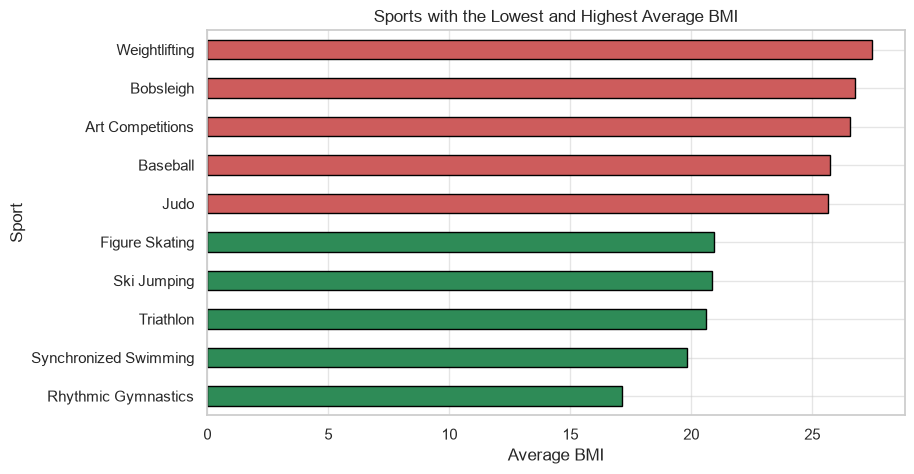

Finding: Rhythmic Gymnastics has the lowest average BMI (17.1) and Weightlifting the highest (27.5).


In [47]:
# Body Mass Index (BMI) by sport, for sports with at least 100 entries
data['BMI'] = data['Weight'] / (data['Height'] / 100) ** 2

sport_counts = data['Sport'].value_counts()
big_sports = sport_counts[sport_counts >= 100].index
sport_bmi = (data[data['Sport'].isin(big_sports)]
             .groupby('Sport')['BMI'].mean().sort_values())

# 5 lowest and 5 highest average BMI
extremes = pd.concat([sport_bmi.head(5), sport_bmi.tail(5)])
colors = ['seagreen'] * 5 + ['indianred'] * 5

extremes.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Sports with the Lowest and Highest Average BMI')
plt.xlabel('Average BMI')
plt.ylabel('Sport')
plt.show()

print(f"Finding: {sport_bmi.index[0]} has the lowest average BMI ({sport_bmi.iloc[0]:.1f}) "
      f"and {sport_bmi.index[-1]} the highest ({sport_bmi.iloc[-1]:.1f}).")

**How to read this:** The sports at each end of the chart show how different sports favour different body types. BMI is only a rough measure (it does not distinguish muscle from fat), so treat it as a fun comparison rather than a health measure.

## 8. Conclusion

### Key findings
1. **Data quality:** 383 duplicate rows were removed. Height and weight are missing for roughly a quarter of rows, so those analyses use only the available data.
2. **The typical athlete:** male in about three quarters of entries, median age **25**, average height **~175.5 cm** and average weight **~70.9 kg**.
3. **Growth:** participation grew from under 100 athletes in 1896 to about **3,000** in 2016, and the Summer/Winter split into separate years is clearly visible after 1992.
4. **Age over time:** average age peaked in the early 1900s (~29 to 30), fell to its lowest point around **1980** (~23.3) and has risen again to about **26**.
5. **Countries:** the **USA** leads in participation and gold medals (747 gold medal rows before correcting for team events).
6. **Body type and sport:** **Basketball** players are the tallest on average (~190.8 cm). The tallest athlete was 223 cm and the heaviest 214 kg.
7. **Medals:** Gold, Silver and Bronze are evenly distributed, and **height alone does not predict the medal type**.
8. Further findings in sections 5 to 7 (female participation, top countries and athletes, BMI by sport) are printed automatically by the code, so the numbers always match the data.

### Limitations
- The data are **70,000 rows** and look like a **sample** of the full Olympic history, so totals may not match official medal tables.
- Each row is an **athlete-event entry**, so counts show entries rather than unique people unless stated.
- Missing height and weight values were left as they are (not filled in).
- Countries are identified by NOC code, and some historical codes (such as YUG) no longer exist.

### Possible next steps
- Compare medals **per capita** or by population and GDP.
- Build a simple **machine learning model** to predict whether an athlete wins a medal.
- Build an interactive **dashboard** (for example with Streamlit or Power BI).
- Study individual countries over time, or the effect of **hosting** the Games on medal counts.

---
*Tools: Python, pandas, NumPy, Matplotlib, Seaborn*